# The whole chain

One pass from the smallest piece to the largest, so the layers are visible in one place. Every
level below consumes the one above it and adds exactly one idea.

| level | what it is | the call |
|---|---|---|
| **modules** | one aircraft, one tick | `Kinematics.step`, `Autopilot.step`, `CNS.sense`, `detect`/`resolve`/`should_resume` |
| **environment** | one encounter, spawn to termination | `run_fleet` → `conflict`, `los`, `min_sep` |
| **estimator** | many encounters → a probability with an interval | `estimate_ipr` → `p_los`, `ci95`, `median_min_sep` |
| **experiment** | many conditions → one row each | `run_experiment` → a table and a response curve |

Nothing here is new: it is the same objects the rest of the handbook introduces one at a time,
assembled in order.

In [1]:
%matplotlib inline
import dataclasses
import math

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.dpi"] = 130

from opencdarr import (
    MC,
    MVP,
    Agent,
    MotionCommand,
    Comm,
    Fixed,
    GnssNavigation,
    LastKnown,
    M600,
    Methods,
    NO_WIND,
    Multirotor,
    PastCPA,
    StateBased,
    Sweep,
    WindField,
    create_aircraft,
    create_conflict,
    estimate_ipr,
    generator,
    geo,
    plot_pairwise,
    root_seed_sequence,
    run_experiment,
    run_fleet,
    spawn,
)
from opencdarr.autopilot import CruiseAutopilot
from opencdarr.autopilot.base import GuidanceMemory
from opencdarr.cns import CNS
from opencdarr.cns.stack import CnsState, CnsStreams
from opencdarr.config import load_config

RPZ, LOOKAHEAD, DT = 50.0, 120.0, 1.0

## Modules — one aircraft, one tick

### The airframe

An `AircraftState` is the aircraft; a `Performance` is its envelope; a `Kinematics` integrates one
from the other. `step` is pure — state in, state out — which is what lets a rare-event estimator
clone it mid-flight later on.

In [2]:
own = create_aircraft(M600, id="OWN", lat=52.0, lon=4.0, trk=0.0, gs=10.0,
                      pos_ci95=10.0, vel_ci95=1.0)
rotor = Multirotor()

# a command to turn east at the same speed, and one second of it
turn_east = MotionCommand(target_velocity=(10.0, 0.0))
after = rotor.step(own, turn_east, M600, DT)

print(f"{'':<8} {'trk [deg]':>10} {'gs [m/s]':>9} {'lat':>10} {'lon':>9}")
for label, s in (("before", own), ("after 1 s", after)):
    print(f"{label:<8} {s.trk:>10.2f} {s.gs:>9.2f} {s.lat:>10.5f} {s.lon:>9.5f}")
print(f"\nM600 envelope: v_max {M600.v_max} m/s, ax {M600.ax} m/s^2"
      f"  -> one second moves the velocity vector by at most {M600.ax * DT:.0f} m/s")

          trk [deg]  gs [m/s]        lat       lon
before         0.00     10.00   52.00000   4.00000
after 1 s      28.68      7.37   52.00006   4.00005

M600 envelope: v_max 18.0 m/s, ax 5.0 m/s^2  -> one second moves the velocity vector by at most 5 m/s


### The autopilot

The airframe answers commands; the autopilot decides what to command when nothing is wrong. It
returns the same vehicle-neutral `MotionCommand`, so the two compose without either knowing about
the other.

In [3]:
autopilot = CruiseAutopilot(heading=own.trk, speed=own.gs)
nominal, memory = autopilot.step(own, GuidanceMemory(), M600)
print(f"nominal command: track {nominal.trk:.1f} deg at {nominal.gs:.2f} m/s")

nominal command: track 0.0 deg at 10.00 m/s


### Wind

Wind is an environment input threaded into `step`, never stored on the state. The envelope applies
to **airspeed**, so a ground-velocity command is met by crabbing — the aircraft points somewhere
other than where it travels.

In [4]:
breeze = WindField.from_met(coming_from_deg=270.0, speed=6.0)   # 6 m/s from the west
print(f"wind: {breeze.w_east:+.1f} m/s east, {breeze.w_north:+.1f} m/s north\n")

print(f"{'':<11} {'ground trk':>11} {'ground gs':>10} {'must point':>11} {'airspeed':>9}")
for label, wind in (("calm", NO_WIND), ("6 m/s wind", breeze)):
    s = rotor.step(own, nominal, M600, DT, wind=wind)
    ve, vn = s.gs * math.sin(math.radians(s.trk)), s.gs * math.cos(math.radians(s.trk))
    air_e, air_n = ve - wind.w_east, vn - wind.w_north          # the airspeed vector
    heading = math.degrees(math.atan2(air_e, air_n)) % 360.0
    print(f"{label:<11} {s.trk:>11.2f} {s.gs:>10.2f} {heading:>11.2f} {math.hypot(air_e, air_n):>9.2f}")

print("\nThe ground track is unchanged -- the command is a ground velocity and the aircraft meets")
print("it. What the wind costs is airspeed, and a nose pointed 31 deg left of where it travels.")

wind: +6.0 m/s east, +0.0 m/s north

             ground trk  ground gs  must point  airspeed
calm               0.00      10.00        0.00     10.00
6 m/s wind         0.00      10.00      329.04     11.66

The ground track is unchanged -- the command is a ground velocity and the aircraft meets
it. What the wind costs is airspeed, and a nose pointed 31 deg left of where it travels.


### CNS — what the aircraft knows

Three interfaces in the order a measurement travels. **Navigation** makes a noisy self-fix and
timestamps it. **Communication** decides whether it is delivered, and how late. **Surveillance**
decides what a receiver believes in between deliveries.

The output is a `Perception` per aircraft: its own fix, and the traffic it currently holds. That is
the *only* thing the separation manager ever sees.

In [5]:
intr = create_conflict(own, intr_id="INT", dpsi=90.0, dcpa=0.0, tlos=90.0, rpz=RPZ)
states = [own, intr]

cns = CNS(navigation=GnssNavigation(), communication=Comm(), surveillance=LastKnown())
nav_seq, comm_seq = spawn(root_seed_sequence(0), 2)
streams = CnsStreams(nav=generator(nav_seq), comm=generator(comm_seq))

state = CnsState.initial(len(states), communication=Comm(), navigation=GnssNavigation())
state, perceptions = cns.sense(states, firing=[0, 1], t=0.0, cns=state, streams=streams)
state, perceptions = cns.sense(states, firing=[0, 1], t=1.0, cns=state, streams=streams)

seen = perceptions[0]
truth_err = geo.qdrdist(own.lat, own.lon, seen.own.lat, seen.own.lon)[1]
print(f"OWN's own fix is off by       {truth_err:6.2f} m")
if seen.traffic:
    held = seen.traffic[0]
    err = geo.qdrdist(intr.lat, intr.lon, held.lat, held.lon)[1]
    print(f"OWN's picture of INT is off by {err:6.2f} m")
else:
    print("OWN holds nothing about INT yet -- that directed pair flies nominal")
print(f"\ntrue separation {geo.qdrdist(own.lat, own.lon, intr.lat, intr.lon)[1]:.1f} m")

OWN's own fix is off by         4.06 m
OWN's picture of INT is off by   4.25 m

true separation 1322.8 m


### CDaRR — detect, resolve, recover

Three more interfaces, each one abstract method. They act on the **perceived** states above, never
on the truth. Recovery runs first each tick (it prunes the active set), then resolution acts on
what remains.

In [6]:
detector, resolver, recovery = StateBased(), MVP(margin=1.05), PastCPA()

conflict = detector.detect(seen.own, seen.traffic[0], RPZ, LOOKAHEAD)
print(f"detect      -> conflict within {LOOKAHEAD:.0f} s: {conflict}")

avoid = resolver.resolve(seen.own, seen.traffic, RPZ)
print(f"resolve     -> track {avoid.trk:.1f} deg at {avoid.gs:.2f} m/s"
      f"   (nominal was {nominal.trk:.1f} deg)")

print(f"should_resume -> {recovery.should_resume(seen.own, seen.traffic[0], RPZ)}"
      "   (still closing, so keep resolving)")

detect      -> conflict within 120 s: True
resolve     -> track 357.2 deg at 10.05 m/s   (nominal was 0.0 deg)
should_resume -> False   (still closing, so keep resolving)


## Environment — one encounter

`run_fleet` is the loop that runs the tick above to termination: perceive, decide, integrate,
repeat until the pair is clear or the clock runs out. It returns one `FleetOutcome` measured on the
**true** states, whatever anyone perceived.

conflict True   los False   min_sep 142.72 m
83 frames, ending at t = 82 s


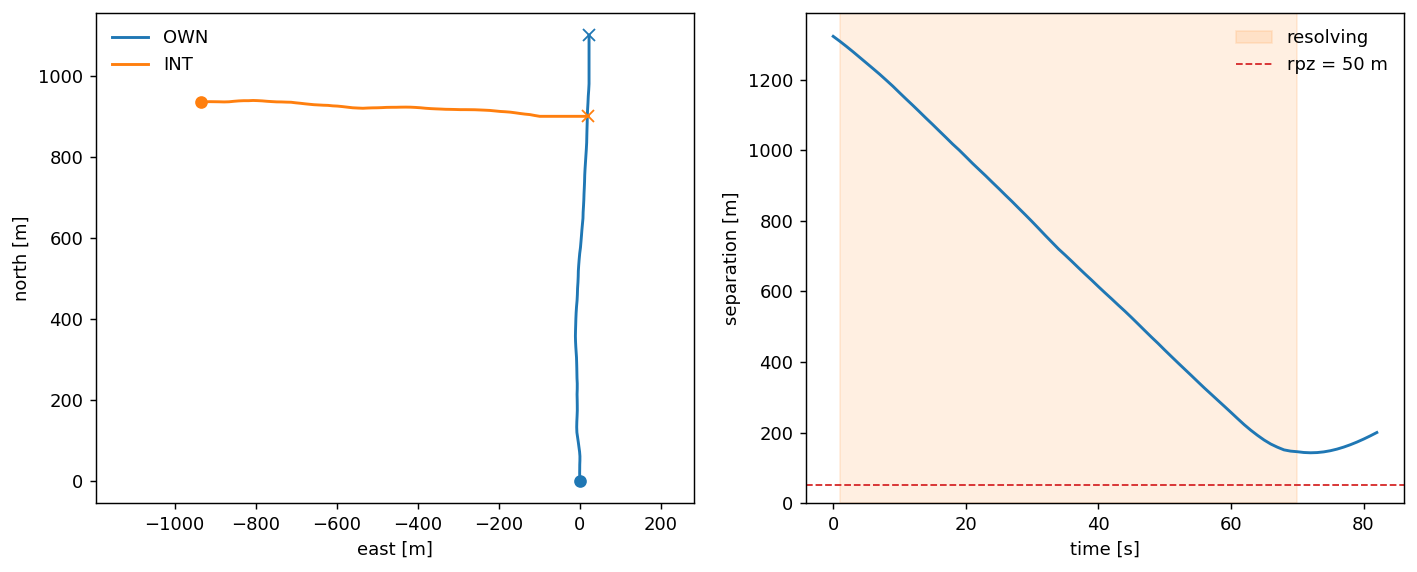

In [7]:
agents = [Agent(own, M600, rotor), Agent(intr, M600, rotor)]
outcome = run_fleet(
    agents, rpz=RPZ, t_lookahead=LOOKAHEAD, dt=DT,
    detector=detector, resolver=resolver, recovery=recovery,
    navigation=GnssNavigation(), rng=generator(nav_seq),
    communication=Comm(), comm_rng=generator(comm_seq),
    surveillance=LastKnown(), wind=breeze,
    t_max=600.0, done_timeout=10.0, record=True,
)
print(f"conflict {outcome.conflict}   los {outcome.los}   min_sep {outcome.min_sep:.2f} m")
print(f"{len(outcome.frames)} frames, ending at t = {outcome.frames[-1].t:.0f} s")

fig = plot_pairwise(outcome, rpz=RPZ)

One encounter is one sample. It came out `los = False`, but that is a fact about this seed, not
about the resolver — change the noise draws and it can go the other way. Turning that into a
statement about *how often* is the next level.

## Estimator — many encounters

`estimate_ipr` samples encounters from a `Config`, runs each through the same `run_fleet`, and
aggregates. The denominator is the number of encounters — chosen by you, not discovered by the run
— so the rate is a genuine binomial and gets a Wilson interval.

In [8]:
base = load_config("../../configs/pairwise.yaml")
cfg = dataclasses.replace(
    base, seed=0, n_encounters=500,
    scenario=dataclasses.replace(base.scenario, speed=10.0, tlos=180.0,
                                 pos_ci95=10.0, vel_ci95=1.0),
)

result = estimate_ipr(cfg, M600, detector, resolver, recovery, GnssNavigation(),
                      Comm(), LastKnown(), kinematics=rotor, wind=breeze,
                      dpsi=45.0, dcpa=0.0)

print(f"P(LoS)          {result.p_los:.3f}   95% CI "
      f"[{result.ci95[0]:.3f}, {result.ci95[1]:.3f}]")
print(f"median min_sep  {result.median_min_sep:.1f} m")
print(f"counts          {result.n_los} of {result.n_encounters}")
print(f"\nthe record behind it: {len(result.min_seps)} separations, so any other threshold is a read")
print(f"P(min_sep < 100) {(np.array(result.min_seps) < 100).mean():.3f}")

P(LoS)          0.000   95% CI [0.000, 0.008]
median min_sep  211.7 m
counts          0 of 500

the record behind it: 500 separations, so any other threshold is a read
P(min_sep < 100) 0.122


## Experiment — many conditions

One estimate answers one question. `run_experiment` declares which parameters vary, runs the
cross-product, and returns one row per condition — the same `Methods` objects, the same estimator,
one level up.

In [9]:
methods = Methods(detector=detector, resolver=resolver, recovery=recovery,
                  navigation=GnssNavigation(), communication=Comm(), surveillance=LastKnown(),
                  kinematics=rotor, perf=M600, wind=breeze)

sweep = run_experiment(
    {"dpsi": Sweep([10.0, 45.0, 90.0]), "pos_ci95": Sweep([10.0, 30.0]),
     "vel_ci95": Fixed(1.0), "dcpa": Fixed(0.0), "tlos": Fixed(180.0), "speed": Fixed(10.0)},
    methods=methods, backend=MC(n_encounters=500),
    base_config=cfg, seed=0, cache=True, n_jobs=4,
)
sweep.frame()[["dpsi", "pos_ci95", "p_los", "p_los_lo", "p_los_hi",
               "median_min_sep", "n_los", "detection_rate"]].round(4)

,dpsi,pos_ci95,p_los,p_los_lo,p_los_hi,median_min_sep,n_los,detection_rate
0,10.0,10.0,0.002,0.0004,0.0112,83.0249,1,0.536
1,10.0,30.0,0.008,0.0031,0.0204,83.0057,4,0.788
2,45.0,10.0,0.000,0.0000,0.0076,211.6599,0,0.444
3,45.0,30.0,0.000,0.0000,0.0076,212.4460,0,0.660
4,90.0,10.0,0.000,0.0000,0.0076,291.3982,0,0.630
5,90.0,30.0,0.000,0.0000,0.0076,313.0081,0,0.754


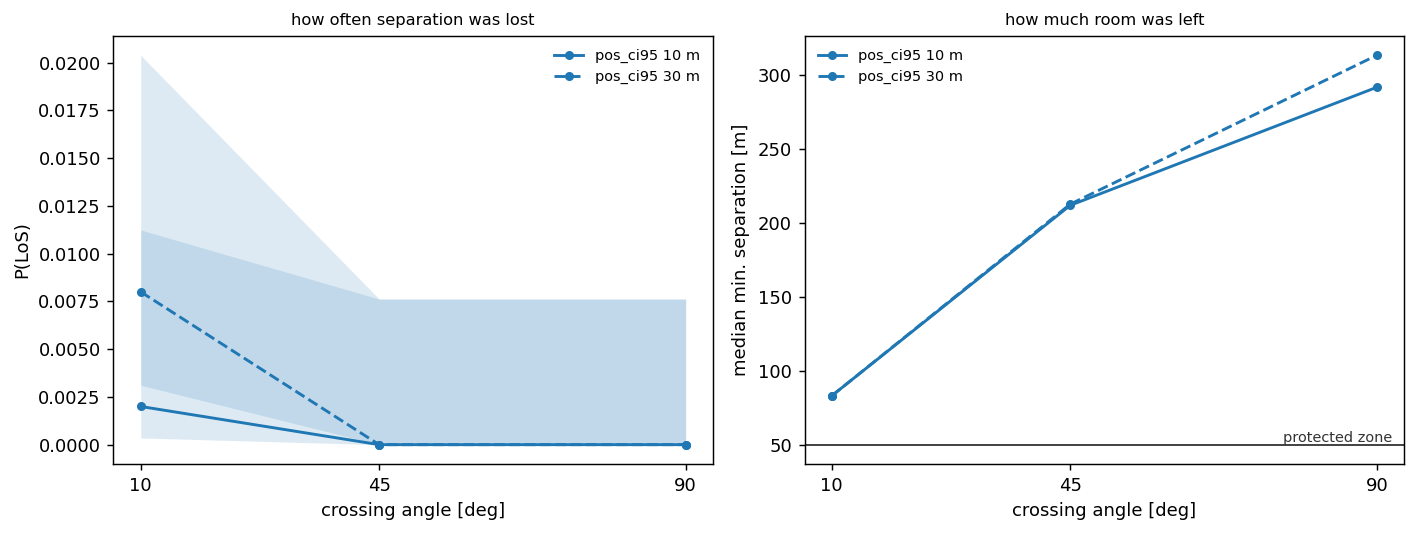

In [10]:
fig, (ax_p, ax_m) = plt.subplots(1, 2, figsize=(11.0, 4.2))
rows = sweep.records()
for pos, style in zip((10.0, 30.0), ("-", "--")):
    g = sorted((r for r in rows if r["pos_ci95"] == pos), key=lambda r: r["dpsi"])
    xs = [r["dpsi"] for r in g]
    ax_p.plot(xs, [r["p_los"] for r in g], style, marker="o", ms=4, lw=1.6,
              color="#1f77b4", label=f"pos_ci95 {pos:.0f} m")
    ax_p.fill_between(xs, [r["p_los_lo"] for r in g], [r["p_los_hi"] for r in g],
                      alpha=0.15, color="#1f77b4", lw=0)
    ax_m.plot(xs, [r["median_min_sep"] for r in g], style, marker="o", ms=4, lw=1.6,
              color="#1f77b4", label=f"pos_ci95 {pos:.0f} m")
ax_m.axhline(RPZ, color="0.2", lw=1.0)
ax_m.annotate("protected zone", (0.98, RPZ), xycoords=("axes fraction", "data"),
              ha="right", va="bottom", fontsize=8, color="0.2")
for ax, ylab, title in ((ax_p, "P(LoS)", "how often separation was lost"),
                        (ax_m, "median min. separation [m]", "how much room was left")):
    ax.set_xlabel("crossing angle [deg]")
    ax.set_ylabel(ylab)
    ax.set_title(title, fontsize=9)
    ax.set_xticks([10, 45, 90])
    ax.legend(frameon=False, fontsize=8, loc="best")
fig.tight_layout()

## The ladder, in one place

Each level took the one above it and added a single idea.

| level | added | the thing it produces |
|---|---|---|
| `Kinematics.step` | physics for one tick | a new `AircraftState` |
| `CNS.sense` | what each aircraft *knows* | a `Perception` per aircraft |
| `detect` / `resolve` / `should_resume` | what it decides to do about it | a `MotionCommand` |
| `run_fleet` | run the tick to termination | one `FleetOutcome` — `conflict`, `los`, `min_sep` |
| `estimate_ipr` | run many encounters, count | `p_los` with a Wilson interval, and the record behind it |
| `run_experiment` | run many conditions, tabulate | one row per condition, with a cache and a provenance card |

Two properties hold all the way up, and both are worth knowing:

- **Every component is swappable at every level.** The objects handed to `run_experiment` in the
  last cell are the same ones called by hand in the first. Nothing is registered, wrapped or
  special-cased, so a class you wrote this morning goes in the same slot as `MVP`.
- **The outcome is always measured on the true states.** Noise changes what the aircraft *do*;
  it never changes what is scored. `pos_ci95` widens the gap between what happened and what was
  believed, and `P(LoS)` is what that gap costs.

Swap `backend=MC(...)` for `backend=IPS(...)` and the same declaration estimates the same quantity
by splitting, for probabilities too small for plain sampling to reach.